## <small>
Copyright (c) 2017-21 Andrew Glassner

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.
</small>



# Deep Learning: A Visual Approach
## by Andrew Glassner, https://glassner.com
### Order: https://nostarch.com/deep-learning-visual-approach
### GitHub: https://github.com/blueberrymusic
------

### What's in this notebook

This notebook is provided as a “behind-the-scenes” look at code used to make some of the figures in this chapter. It is cleaned up a bit from the original code that I hacked together, and is only lightly commented. I wrote the code to be easy to interpret and understand, even for those who are new to Python. I tried never to be clever or even more efficient at the cost of being harder to understand. The code is in Python3, using the versions of libraries as of April 2021. 

This notebook may contain additional code to create models and images not in the book. That material is included here to demonstrate additional techniques.

Note that I've included the output cells in this saved notebook, but Jupyter doesn't save the variables or data that were used to generate them. To recreate any cell's output, evaluate all the cells from the start up to that cell. A convenient way to experiment is to first choose "Restart & Run All" from the Kernel menu, so that everything's been defined and is up to date. Then you can experiment using the variables, data, functions, and other stuff defined in this notebook.

### A note on variation of output

Note as always that due to the use of random numbers, some of the results here may differ from those in the book (since I re-ran everything to prepare this notebook), and will probably be different yet again if you run this notebook.

## Chapter 18: Autoencoders - Notebook 2: MNIST 1

In [61]:
# Some code inspired or based on:
#    https://blog.keras.io/building-autoencoders-in-keras.html
#    https://jmetzen.github.io/2015-11-27/vae.html
#    https://arxiv.org/pdf/1606.05908.pdf  (https://github.com/cdoersch/vae_tutorial)
#

In [62]:
from keras.api.datasets import mnist
from keras.api.models import Sequential, Model
from keras.api.layers import Dense, Input
import numpy as np
import h5py
from pathlib import Path
import matplotlib.pyplot as plt

from keras._tf_keras.keras import backend as keras_backend
keras_backend.set_image_data_format('channels_last')

In [63]:
# Workaround for Keras issues on Mac computers (you can comment this
# out if you're not on a Mac, or not having problems)
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [64]:
# Make a File_Helper for saving and loading files.

save_files = False

import os, sys, inspect
current_dir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
sys.path.insert(0, os.path.dirname(current_dir)) # path to parent dir
from DLBasics_Utilities import File_Helper
file_helper = File_Helper(save_files)

In [88]:
from random import randint

random_seed = randint(1, 10000)
np.random.seed(random_seed)

# Read MNIST data. We won't be using the y_train or y_test data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
pixels_per_image = np.prod(X_train.shape[1:])

# Cast values into the current floating-point type
X_train = keras_backend.cast_to_floatx(X_train)
X_test = keras_backend.cast_to_floatx(X_test)

# Normalize the range from [0,255] to [0,1]
X_train /= 255.
X_test /= 255.

# Reshape the data into a grid with one row per sample, each row 784 (28*28) pixels
X_train = X_train.reshape((len(X_train), pixels_per_image))
X_test = X_test.reshape((len(X_test), pixels_per_image))

print("X_train.shape = ",X_train.shape, " X_test.shape = ",X_test.shape)

X_train.shape =  (60000, 784)  X_test.shape =  (10000, 784)


In [71]:
# Show a grid of MNIST images and our prediction for each one

def draw_predictions_set(predictions, filename=None):
    plt.figure(figsize=(8, 4))
    for i in range(8):
        plt.subplot(2, 8, i+1)
        plt.imshow(X_test[i].reshape(28, 28), vmin=0, vmax=1, cmap="gray")
        ax = plt.gca()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        plt.subplot(2, 8, i+9)
        plt.imshow(predictions[i].reshape(28, 28), vmin=0, vmax=1, cmap="gray")
        ax = plt.gca()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.tight_layout()
    file_helper.save_figure(filename+'-predictions')
    plt.show()

In [67]:
# Build and train our first autoencoder
num_latent_vars = 20

AE1 = Sequential()
AE1.add(Input((pixels_per_image,)))
AE1.add(Dense(num_latent_vars, activation='relu'))
AE1.add(Dense(pixels_per_image, activation='sigmoid'))
AE1.compile(optimizer='adam', loss='binary_crossentropy')

weights_filename = "NB2-AE1-weights"
np.random.seed(42)
if not file_helper.load_model_weights(AE1, weights_filename):
    AE1.fit(X_train, X_train,
               epochs=50, batch_size=128, shuffle=True,
               verbose=2,
               validation_data=(X_test, X_test))
    file_helper.save_model_weights(AE1, weights_filename)

Epoch 1/50
469/469 - 3s - 6ms/step - loss: 0.2498 - val_loss: 0.1776
Epoch 2/50
469/469 - 1s - 3ms/step - loss: 0.1618 - val_loss: 0.1472
Epoch 3/50
469/469 - 1s - 3ms/step - loss: 0.1399 - val_loss: 0.1324
Epoch 4/50
469/469 - 1s - 2ms/step - loss: 0.1303 - val_loss: 0.1261
Epoch 5/50
469/469 - 1s - 2ms/step - loss: 0.1251 - val_loss: 0.1216
Epoch 6/50
469/469 - 1s - 2ms/step - loss: 0.1215 - val_loss: 0.1187
Epoch 7/50
469/469 - 1s - 2ms/step - loss: 0.1193 - val_loss: 0.1170
Epoch 8/50
469/469 - 1s - 2ms/step - loss: 0.1180 - val_loss: 0.1160
Epoch 9/50
469/469 - 1s - 2ms/step - loss: 0.1173 - val_loss: 0.1156
Epoch 10/50
469/469 - 1s - 3ms/step - loss: 0.1169 - val_loss: 0.1153
Epoch 11/50
469/469 - 1s - 2ms/step - loss: 0.1167 - val_loss: 0.1149
Epoch 12/50
469/469 - 1s - 2ms/step - loss: 0.1165 - val_loss: 0.1149
Epoch 13/50
469/469 - 1s - 2ms/step - loss: 0.1163 - val_loss: 0.1149
Epoch 14/50
469/469 - 1s - 2ms/step - loss: 0.1162 - val_loss: 0.1147
Epoch 15/50
469/469 - 1s - 2m

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step


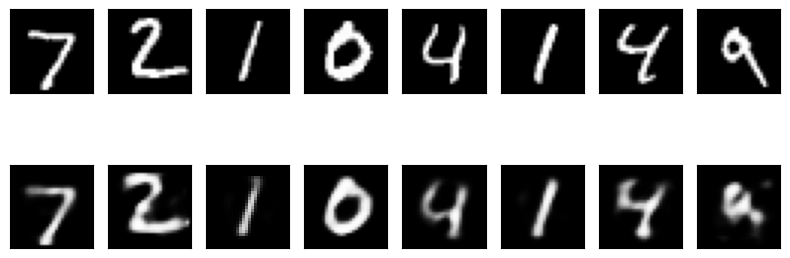

In [72]:
predictions1 = AE1.predict(X_test)
draw_predictions_set(predictions1, 'NB2-MLP-AE1')

In [73]:
# Build and train our second, more compress-y autoencoder
num_latent_vars = 10

AE2 = Sequential()
AE2.add(Dense(num_latent_vars, input_dim=pixels_per_image, activation='relu'))
AE2.add(Dense(pixels_per_image, activation='sigmoid'))
AE2.compile(optimizer='adam', loss='binary_crossentropy')

weights_filename = "NB2-AE2-weights"
np.random.seed(42)
if not file_helper.load_model_weights(AE2, weights_filename):
    AE2.fit(X_train, X_train,
               epochs=50, batch_size=128, shuffle=True,
               verbose=2,
               validation_data=(X_test, X_test))
    file_helper.save_model_weights(AE2, weights_filename)

Epoch 1/50
469/469 - 2s - 5ms/step - loss: 0.2799 - val_loss: 0.2033
Epoch 2/50
469/469 - 1s - 3ms/step - loss: 0.1876 - val_loss: 0.1747
Epoch 3/50
469/469 - 1s - 2ms/step - loss: 0.1711 - val_loss: 0.1661
Epoch 4/50
469/469 - 1s - 3ms/step - loss: 0.1658 - val_loss: 0.1627
Epoch 5/50
469/469 - 1s - 2ms/step - loss: 0.1631 - val_loss: 0.1605
Epoch 6/50
469/469 - 1s - 3ms/step - loss: 0.1611 - val_loss: 0.1589
Epoch 7/50
469/469 - 1s - 2ms/step - loss: 0.1596 - val_loss: 0.1573
Epoch 8/50
469/469 - 1s - 2ms/step - loss: 0.1584 - val_loss: 0.1562
Epoch 9/50
469/469 - 1s - 2ms/step - loss: 0.1575 - val_loss: 0.1555
Epoch 10/50
469/469 - 1s - 2ms/step - loss: 0.1568 - val_loss: 0.1550
Epoch 11/50
469/469 - 1s - 3ms/step - loss: 0.1563 - val_loss: 0.1543
Epoch 12/50
469/469 - 1s - 2ms/step - loss: 0.1559 - val_loss: 0.1541
Epoch 13/50
469/469 - 1s - 2ms/step - loss: 0.1556 - val_loss: 0.1538
Epoch 14/50
469/469 - 1s - 2ms/step - loss: 0.1553 - val_loss: 0.1534
Epoch 15/50
469/469 - 1s - 2m

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step


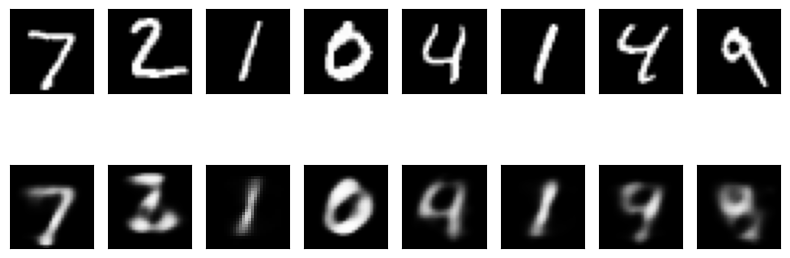

In [74]:
predictions2 = AE2.predict(X_test)
draw_predictions_set(predictions2, 'NB2-MLP-AE2')

In [75]:
# Build and train our third, super compress-y autoencoder
num_latent_vars = 3

AE3 = Sequential()
AE3.add(Dense(num_latent_vars, input_dim=pixels_per_image, activation='relu'))
AE3.add(Dense(pixels_per_image, activation='sigmoid'))
AE3.compile(optimizer='adam', loss='binary_crossentropy')

weights_filename = "NB2-AE3-weights"
np.random.seed(42)
if not file_helper.load_model_weights(AE3, weights_filename):
    AE3.fit(X_train, X_train,
               epochs=50, batch_size=128, shuffle=True,
               verbose=2,
               validation_data=(X_test, X_test))
    file_helper.save_model_weights(AE3, weights_filename)

Epoch 1/50
469/469 - 2s - 5ms/step - loss: 0.3212 - val_loss: 0.2564
Epoch 2/50
469/469 - 1s - 3ms/step - loss: 0.2426 - val_loss: 0.2331
Epoch 3/50
469/469 - 1s - 3ms/step - loss: 0.2317 - val_loss: 0.2275
Epoch 4/50
469/469 - 1s - 2ms/step - loss: 0.2274 - val_loss: 0.2241
Epoch 5/50
469/469 - 1s - 2ms/step - loss: 0.2248 - val_loss: 0.2224
Epoch 6/50
469/469 - 1s - 2ms/step - loss: 0.2231 - val_loss: 0.2209
Epoch 7/50
469/469 - 1s - 2ms/step - loss: 0.2217 - val_loss: 0.2198
Epoch 8/50
469/469 - 1s - 2ms/step - loss: 0.2207 - val_loss: 0.2189
Epoch 9/50
469/469 - 1s - 2ms/step - loss: 0.2198 - val_loss: 0.2183
Epoch 10/50
469/469 - 1s - 2ms/step - loss: 0.2190 - val_loss: 0.2177
Epoch 11/50
469/469 - 1s - 2ms/step - loss: 0.2184 - val_loss: 0.2170
Epoch 12/50
469/469 - 1s - 2ms/step - loss: 0.2178 - val_loss: 0.2166
Epoch 13/50
469/469 - 1s - 2ms/step - loss: 0.2172 - val_loss: 0.2162
Epoch 14/50
469/469 - 1s - 2ms/step - loss: 0.2168 - val_loss: 0.2157
Epoch 15/50
469/469 - 1s - 2m

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step


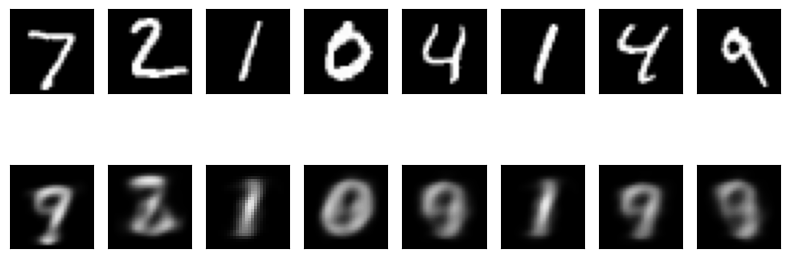

In [76]:
predictions3 = AE3.predict(X_test)
draw_predictions_set(predictions3, 'NB2-MLP-AE3')

In [77]:
# A deeper autoencoder

num_latent_vars = 20

AE4 = Sequential()
AE4.add(Dense(512, input_dim=pixels_per_image, activation='relu'))
AE4.add(Dense(256, activation='relu'))
AE4.add(Dense(num_latent_vars, activation='relu'))
AE4.add(Dense(256, activation='relu'))
AE4.add(Dense(512, activation='relu'))
AE4.add(Dense(pixels_per_image, activation='sigmoid'))
AE4.compile(optimizer='adam', loss='binary_crossentropy')

weights_filename = "NB2-AE4-weights"
np.random.seed(42)
if not file_helper.load_model_weights(AE4, weights_filename):
    AE4.fit(X_train, X_train,
               epochs=50, batch_size=128, shuffle=True,
               verbose=2,
               validation_data=(X_test, X_test))
    file_helper.save_model_weights(AE4, weights_filename)

Epoch 1/50
469/469 - 5s - 11ms/step - loss: 0.1727 - val_loss: 0.1181
Epoch 2/50
469/469 - 3s - 7ms/step - loss: 0.1118 - val_loss: 0.1054
Epoch 3/50
469/469 - 3s - 7ms/step - loss: 0.1038 - val_loss: 0.1003
Epoch 4/50
469/469 - 3s - 7ms/step - loss: 0.0996 - val_loss: 0.0975
Epoch 5/50
469/469 - 3s - 7ms/step - loss: 0.0969 - val_loss: 0.0954
Epoch 6/50
469/469 - 3s - 7ms/step - loss: 0.0949 - val_loss: 0.0951
Epoch 7/50
469/469 - 3s - 7ms/step - loss: 0.0935 - val_loss: 0.0925
Epoch 8/50
469/469 - 3s - 7ms/step - loss: 0.0923 - val_loss: 0.0917
Epoch 9/50
469/469 - 3s - 7ms/step - loss: 0.0912 - val_loss: 0.0912
Epoch 10/50
469/469 - 3s - 7ms/step - loss: 0.0904 - val_loss: 0.0901
Epoch 11/50
469/469 - 3s - 7ms/step - loss: 0.0896 - val_loss: 0.0896
Epoch 12/50
469/469 - 3s - 7ms/step - loss: 0.0890 - val_loss: 0.0892
Epoch 13/50
469/469 - 3s - 7ms/step - loss: 0.0884 - val_loss: 0.0887
Epoch 14/50
469/469 - 3s - 7ms/step - loss: 0.0879 - val_loss: 0.0893
Epoch 15/50
469/469 - 3s - 7

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


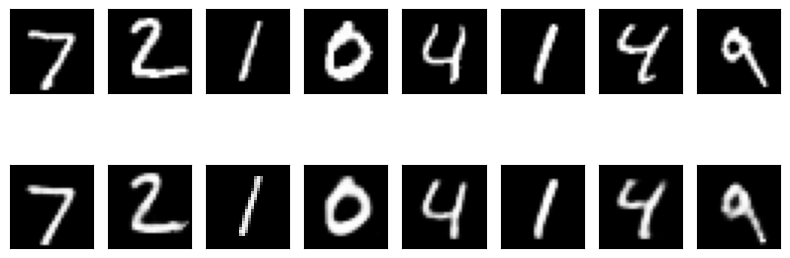

In [78]:
predictions4 = AE4.predict(X_test)
draw_predictions_set(predictions4, 'NB2-MLP-AE4')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


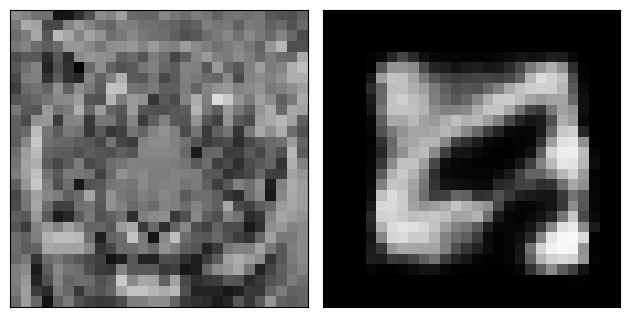

In [79]:
# Tyger, tyger, burning bright...

from PIL import Image

filepath = file_helper.get_input_file_path("tiger-gray-28-28.png")
im = Image.open(filepath) #Can be many different formats.
pix = im.load()
tiger = np.zeros((1,784))
for y in range(28):
    for x in range(28):
        tiger[0,(y*28)+x] = pix[x,y][0]/255.
        
predicted_tiger = AE4.predict(tiger)

plt.subplot(1, 2, 1)
plt.imshow(np.reshape(tiger, (28, 28)), vmin=0, vmax=1, cmap="gray")
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.subplot(1, 2, 2)
plt.imshow(np.reshape(predicted_tiger, (28, 28)), vmin=0, vmax=1, cmap="gray")
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.tight_layout()
file_helper.save_figure('NB2-MLP-AE4-tiger-pair')
plt.show()

In [16]:
##### Second set of figures for the "Exploring" section

In [17]:
# rebuild AE4 with the Functional API so we can play with the decoder alone
from keras.api.layers import Input

num_latent_vars = 20

AE5_encoder_input = Input(shape=(784,))
AE5_encoder_512 = Dense(512, activation='relu')
AE5_encoder_256 = Dense(256, activation='relu')
AE5_encoder_latent = Dense(num_latent_vars, activation='relu')

AE5_decoder_256 = Dense(256, activation='relu')
AE5_decoder_512 = Dense(512, activation='relu')
AE5_decoder_out = Dense(784, activation='sigmoid')

AE5_encoder_step_1 = AE5_encoder_512(AE5_encoder_input)
AE5_encoder_step_2 = AE5_encoder_256(AE5_encoder_step_1)
AE5_encoder_output = AE5_encoder_latent(AE5_encoder_step_2)

AE5_decoder_step_1 = AE5_decoder_256(AE5_encoder_output)
AE5_decoder_step_2 = AE5_decoder_512(AE5_decoder_step_1)
AE5_decoder_output = AE5_decoder_out(AE5_decoder_step_2)

AE5 = Model(AE5_encoder_input, AE5_decoder_output)

AE5_encoder_only_model = Model(AE5_encoder_input, AE5_encoder_output)

AE5_decoder_only_input = Input(shape=(num_latent_vars,))
AE5_decoder_only_step_1 = AE5_decoder_256(AE5_decoder_only_input)
AE5_decoder_only_step_2 = AE5_decoder_512(AE5_decoder_only_step_1)
AE5_decoder_only_output = AE5_decoder_out(AE5_decoder_only_step_2)
AE5_decoder_only_model = Model(AE5_decoder_only_input, AE5_decoder_only_output)

In [80]:
AE5.compile(optimizer='adam', loss='binary_crossentropy')

weights_filename = "NB2-AE5-weights"
np.random.seed(42)
if not file_helper.load_model_weights(AE5, weights_filename):
    AE5.fit(X_train, X_train,
               epochs=50, batch_size=128, shuffle=True,
               verbose=2,
               validation_data=(X_test, X_test))
    file_helper.save_model_weights(AE5, weights_filename)

Epoch 1/50
469/469 - 5s - 11ms/step - loss: 0.1544 - val_loss: 0.1121
Epoch 2/50
469/469 - 3s - 7ms/step - loss: 0.1071 - val_loss: 0.1022
Epoch 3/50
469/469 - 3s - 7ms/step - loss: 0.1005 - val_loss: 0.0977
Epoch 4/50
469/469 - 3s - 7ms/step - loss: 0.0970 - val_loss: 0.0952
Epoch 5/50
469/469 - 3s - 7ms/step - loss: 0.0946 - val_loss: 0.0935
Epoch 6/50
469/469 - 3s - 7ms/step - loss: 0.0929 - val_loss: 0.0921
Epoch 7/50
469/469 - 3s - 7ms/step - loss: 0.0916 - val_loss: 0.0910
Epoch 8/50
469/469 - 3s - 7ms/step - loss: 0.0906 - val_loss: 0.0901
Epoch 9/50
469/469 - 3s - 7ms/step - loss: 0.0896 - val_loss: 0.0896
Epoch 10/50
469/469 - 3s - 7ms/step - loss: 0.0889 - val_loss: 0.0892
Epoch 11/50
469/469 - 3s - 7ms/step - loss: 0.0882 - val_loss: 0.0886
Epoch 12/50
469/469 - 3s - 7ms/step - loss: 0.0877 - val_loss: 0.0881
Epoch 13/50
469/469 - 3s - 7ms/step - loss: 0.0871 - val_loss: 0.0879
Epoch 14/50
469/469 - 3s - 7ms/step - loss: 0.0867 - val_loss: 0.0873
Epoch 15/50
469/469 - 3s - 7

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


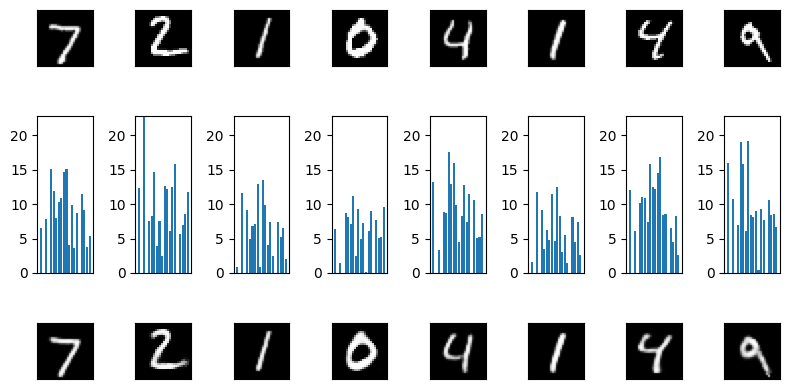

In [81]:
# show the input data, its latent values, and the corresponding predicted images
np.random.seed(random_seed)
encoder_predictions = AE5_encoder_only_model.predict(X_test)

plt.figure(figsize=(8, 5))
latent_min = np.min(encoder_predictions[0:5])
latent_max = np.max(encoder_predictions[0:5])
for i in range(8):
    plt.subplot(3, 8, i+1)
    plt.imshow(X_test[i].reshape(28, 28), vmin=0, vmax=1, cmap="gray")
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    plt.subplot(3, 8, i+9)
    plt.bar(np.arange(len(encoder_predictions[i])), encoder_predictions[i])
    plt.xticks([], [])
    plt.ylim(latent_min, latent_max)
    
    plt.subplot(3, 8, i+17)
    decoder_model_input = np.resize(encoder_predictions[i], (1, len(encoder_predictions[i])))
    decoder_prediction = AE5_decoder_only_model.predict(decoder_model_input)
    plt.imshow(decoder_prediction.reshape(28, 28), vmin=0, vmax=1, cmap="gray")
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.tight_layout()
file_helper.save_figure("NB2-MLP-AE5-latents-and-output")
plt.show()

In [82]:
# show the latent values and the corresponding predicted images
# this makes big vertical spaces between the 
def show_latents_and_predictions(predictions, filename=None):
    plt.figure(figsize=(8, 4))
    latent_min = np.min(predictions[0:8])
    latent_max = np.max(predictions[0:8])
    for i in range(8):
        plt.subplot(2, 8, i+1)
        plt.bar(np.arange(len(predictions[i])), predictions[i])
        plt.xticks([], [])
        plt.ylim(latent_min, latent_max)

        plt.subplot(2, 8, i+9)
        decoder_model_input = np.resize(predictions[i], (1, len(predictions[i])))
        decoder_prediction = AE5_decoder_only_model.predict(decoder_model_input)
        plt.imshow(decoder_prediction.reshape(28, 28), vmin=0, vmax=1, cmap="gray")
        ax = plt.gca()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.tight_layout()
    file_helper.save_figure(filename)
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


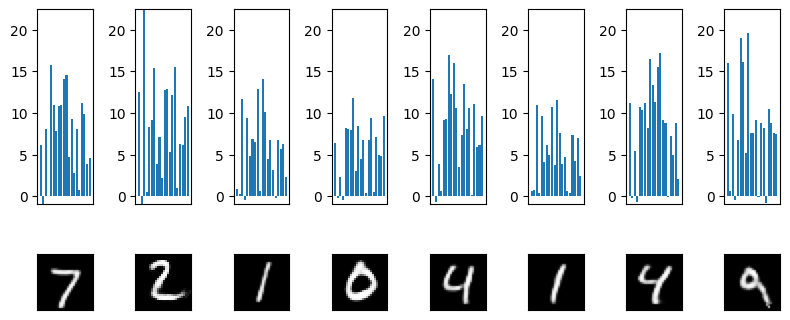

In [90]:
# add [-1,1] noise to all values
encoder_predictions = np.array(AE5_encoder_only_model.predict(X_test))
np.random.seed()
noise = 1
for i in range(encoder_predictions.shape[0]):
    for j in range(len(encoder_predictions[i])):
        encoder_predictions[i][j] += np.random.uniform(low=-noise, high=noise)
show_latents_and_predictions(encoder_predictions, 'NB2-MLP-AE5-prediction-latent-values-with-noise-1')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


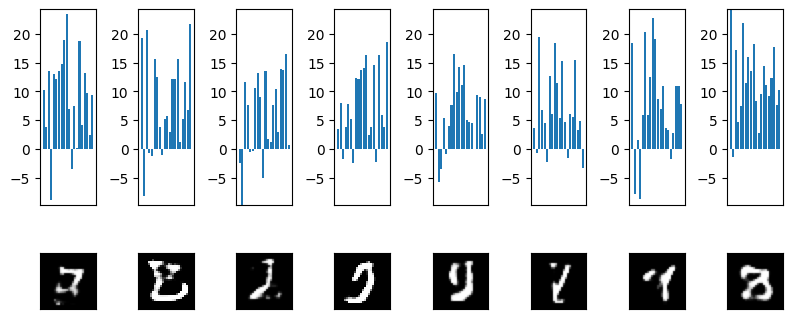

In [91]:
# add [-10,10] noise to all values
encoder_predictions = np.array(AE5_encoder_only_model.predict(X_test))
np.random.seed(random_seed)
noise = 10
for i in range(encoder_predictions.shape[0]):
    for j in range(len(encoder_predictions[i])):
        encoder_predictions[i][j] += np.random.uniform(low=-noise, high=noise)
show_latents_and_predictions(encoder_predictions, 'NB2-MLP-AE5-prediction-latent-values-with-noise-10')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


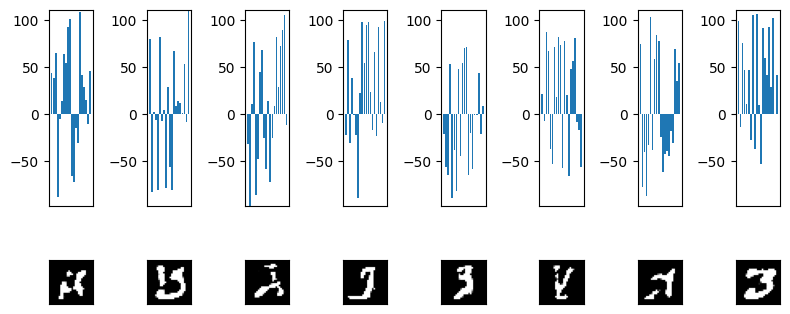

In [92]:
# add [-100,100] noise to all values
encoder_predictions = np.array(AE5_encoder_only_model.predict(X_test))
np.random.seed(random_seed)
noise = 100
for i in range(encoder_predictions.shape[0]):
    for j in range(len(encoder_predictions[i])):
        encoder_predictions[i][j] += np.random.uniform(low=-noise, high=noise)
show_latents_and_predictions(encoder_predictions, 'NB2-MLP-AE5-prediction-latent-values-with-noise-100')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


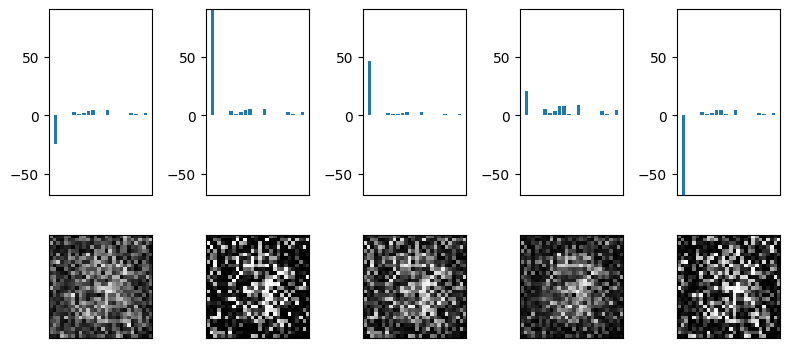

In [24]:
# add [-100,100] noise to just first index
encoder_predictions = np.array(AE5_encoder_only_model.predict(X_test))
np.random.seed(random_seed)
noise = 100
for i in range(encoder_predictions.shape[0]):
    encoder_predictions[i][0] += np.random.uniform(low=-noise, high=noise)
show_latents_and_predictions(encoder_predictions, 'NB2-MLP-AE5-prediction-latent-values-with-noise-100-just-index-0')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


IndexError: index 5 is out of bounds for axis 0 with size 5

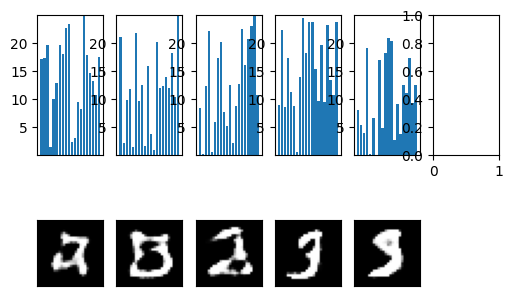

In [93]:
# all latent values are noise
encoder_predictions = np.zeros((5,20))
np.random.seed(random_seed)
noise = 10
for i in range(encoder_predictions.shape[0]):
    encoder_predictions[i] = np.random.uniform(low=0, high=25, size = len(encoder_predictions[i]))
show_latents_and_predictions(encoder_predictions, 'NB2-MLP-AE5-prediction-latent-values-just-noise')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


IndexError: index 5 is out of bounds for axis 0 with size 5

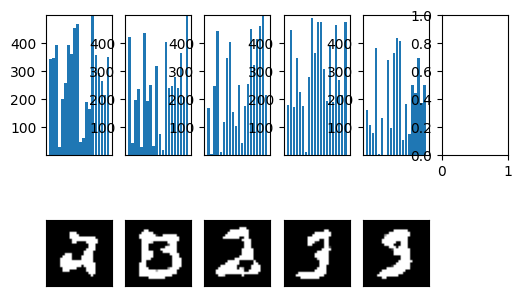

In [94]:
# all latent values are noise
encoder_predictions = np.zeros((5,20))
np.random.seed(random_seed)
noise = 500
for i in range(encoder_predictions.shape[0]):
    encoder_predictions[i] = np.random.uniform(low=0, high=noise, size = len(encoder_predictions[i]))
show_latents_and_predictions(encoder_predictions, 'NB2-MLP-AE5-prediction-latent-values-just-noise-500')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


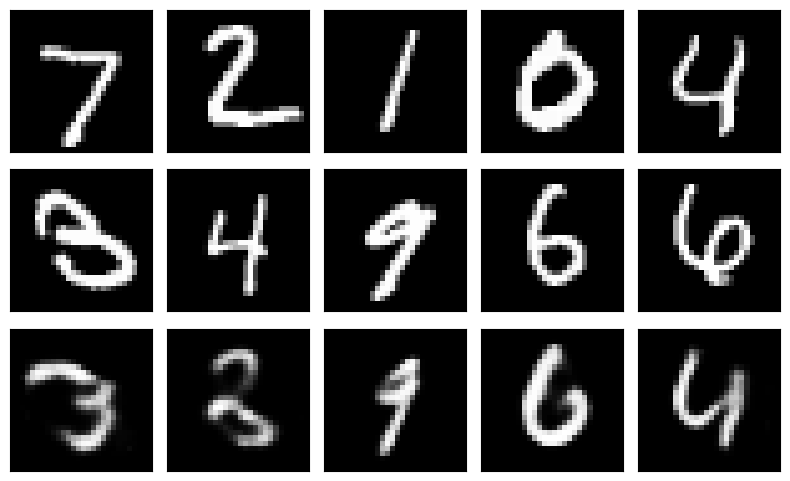

In [95]:
# blend latents for two test images and decompress
encoder_predictions = np.array(AE5_encoder_only_model.predict(X_test))
np.random.seed(random_seed)

plt.figure(figsize=(8, 5))
offset = 18
for i in range(5):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    plt.subplot(3, 5, i+6)
    plt.imshow(X_test[i+offset].reshape(28, 28), cmap="gray")
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    plt.subplot(3, 5, i+11)
    latent0 = encoder_predictions[i]
    latent1 = encoder_predictions[i+offset]
    latent_mix = [(latent0[i]+latent1[i])/2. for i in range(len(latent0))]
    latent_mix = np.reshape(latent_mix, (1,len(latent_mix)))
    decoder_prediction = AE5_decoder_only_model.predict(latent_mix)
    plt.imshow(decoder_prediction.reshape(28, 28), cmap="gray")
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.tight_layout()
file_helper.save_figure("NB2-MLP-AE5-blend-grid")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


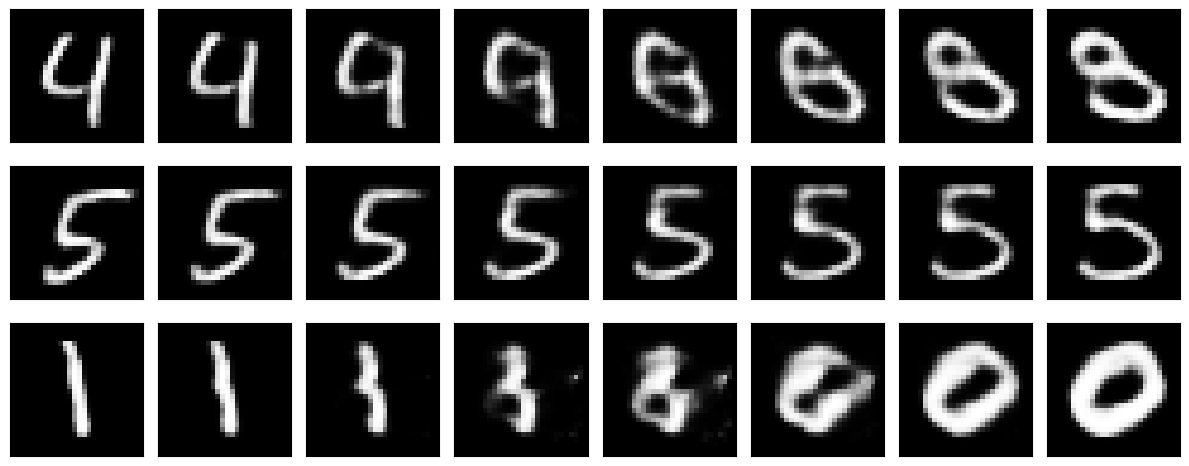

In [97]:
# blend latents for two test images and decompress
encoder_predictions = np.array(AE5_encoder_only_model.predict(X_test))
np.random.seed(random_seed)

steps = 8
plt.figure(figsize=(12, 5))
latent0_list = [ encoder_predictions[4], encoder_predictions[23], encoder_predictions[29]]
latent1_list = [ encoder_predictions[18], encoder_predictions[15], encoder_predictions[25]]

for r in range(3):
    latent0 = latent0_list[r]
    latent1 = latent1_list[r]
    for i in range(steps): 
        plt.subplot(3, steps, (steps*r)+(i+1))
        alpha = i/(steps-1.0)
        latent_mix = [latent0[i]+(alpha*(latent1[i]-latent0[i])) for i in range(len(latent0))]
        latent_mix = np.reshape(latent_mix, (1,len(latent_mix)))
        decoder_prediction = AE5_decoder_only_model.predict(latent_mix)
        plt.imshow(decoder_prediction.reshape(28, 28), cmap="gray")
        ax = plt.gca()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
plt.tight_layout()
file_helper.save_figure("NB2-MLP-AE5-blend-linear")
plt.show()

In [99]:
# make a functional model with 2 latent variables for the scatter plot
from keras.api.layers import Input

num_latent_vars = 2

AE6_encoder_input = Input(shape=(784,))
AE6_encoder_512 = Dense(512, activation='relu')
AE6_encoder_256 = Dense(256, activation='relu')
AE6_encoder_latent = Dense(num_latent_vars, activation='relu')

AE6_decoder_256 = Dense(256, activation='relu')
AE6_decoder_512 = Dense(512, activation='relu')
AE6_decoder_out = Dense(784, activation='sigmoid')

AE6_encoder_step_1 = AE6_encoder_512(AE6_encoder_input)
AE6_encoder_step_2 = AE6_encoder_256(AE6_encoder_step_1)
AE6_encoder_output = AE6_encoder_latent(AE6_encoder_step_2)

AE6_decoder_step_1 = AE6_decoder_256(AE6_encoder_output)
AE6_decoder_step_2 = AE6_decoder_512(AE6_decoder_step_1)
AE6_decoder_output = AE6_decoder_out(AE6_decoder_step_2)

AE6 = Model(AE6_encoder_input, AE6_decoder_output)

AE6_encoder_only_model = Model(AE6_encoder_input, AE6_encoder_output)

AE6_decoder_only_input = Input(shape=(num_latent_vars,))
AE6_decoder_only_step_1 = AE6_decoder_256(AE6_decoder_only_input)
AE6_decoder_only_step_2 = AE6_decoder_512(AE6_decoder_only_step_1)
AE6_decoder_only_output = AE6_decoder_out(AE6_decoder_only_step_2)
AE6_decoder_only_model = Model(AE6_decoder_only_input, AE6_decoder_only_output)

AE6.compile(optimizer='adam', loss='binary_crossentropy')

weights_filename = "NB2-AE6-weights"
np.random.seed(42)
if not file_helper.load_model_weights(AE6, weights_filename):
    AE6.fit(X_train, X_train,
               epochs=50, batch_size=128, shuffle=True,
               verbose=2,
               validation_data=(X_test, X_test))
    file_helper.save_model_weights(AE6, weights_filename)

Epoch 1/50
469/469 - 5s - 11ms/step - loss: 0.2365 - val_loss: 0.2073
Epoch 2/50
469/469 - 3s - 7ms/step - loss: 0.2009 - val_loss: 0.1954
Epoch 3/50
469/469 - 3s - 7ms/step - loss: 0.1924 - val_loss: 0.1887
Epoch 4/50
469/469 - 3s - 7ms/step - loss: 0.1873 - val_loss: 0.1853
Epoch 5/50
469/469 - 3s - 7ms/step - loss: 0.1838 - val_loss: 0.1823
Epoch 6/50
469/469 - 3s - 7ms/step - loss: 0.1811 - val_loss: 0.1797
Epoch 7/50
469/469 - 3s - 7ms/step - loss: 0.1791 - val_loss: 0.1786
Epoch 8/50
469/469 - 3s - 7ms/step - loss: 0.1776 - val_loss: 0.1777
Epoch 9/50
469/469 - 3s - 7ms/step - loss: 0.1762 - val_loss: 0.1766
Epoch 10/50
469/469 - 3s - 7ms/step - loss: 0.1755 - val_loss: 0.1754
Epoch 11/50
469/469 - 3s - 7ms/step - loss: 0.1744 - val_loss: 0.1748
Epoch 12/50
469/469 - 3s - 7ms/step - loss: 0.1735 - val_loss: 0.1737
Epoch 13/50
469/469 - 3s - 7ms/step - loss: 0.1727 - val_loss: 0.1733
Epoch 14/50
469/469 - 3s - 7ms/step - loss: 0.1723 - val_loss: 0.1733
Epoch 15/50
469/469 - 3s - 7

In [101]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
  
# scatter plot from AE6
def draw_scatter(diameter, limits=None, filename=None):
    encoder_predictions = np.array(AE6_encoder_only_model.predict(X_test))
    np.random.seed(random_seed)

    plt.clf()
    fig = plt.figure(figsize=(10, 10))

    ax = fig.add_subplot(111, aspect='equal')

    # display a 2D plot of the digit classes in the latent space
    clrs = [ 'red', 'sandybrown', 'sienna', 'gold', 'palegreen',
            'limegreen', 'deepskyblue', 'blue', 'plum', 'magenta' ]

    for i in range(len(encoder_predictions)):
        p = patches.Circle(encoder_predictions[i], diameter,
                            edgecolor='black', facecolor=clrs[y_test[i]])
        ax.add_patch(p)

    handle_list = []
    for i in range(10):
        p = patches.Patch(color=clrs[i], label=str(i))
        handle_list.append(p)
    ax.legend(handles=handle_list, loc='upper right', shadow=True)

    if limits:
        (pxmin, pxmax, pymin, pymax) = limits
    else:
        xmin = np.min(encoder_predictions[:,0])
        xmax = np.max(encoder_predictions[:,0])
        pxmin = xmin - (.05 * (xmax-xmin))
        pxmax = xmax + (.15 * (xmax-xmin))
        ymin = np.min(encoder_predictions[:,1])
        ymax = np.max(encoder_predictions[:,1])
        pymin = ymin - (.05 * (ymax-ymin))
        pymax = ymax + (.05 * (ymax-ymin))
    ax.set_ylim([pymin, pymax])
    ax.set_xlim([pxmin, pxmax])

    file_helper.save_figure(filename)

    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


<Figure size 640x480 with 0 Axes>

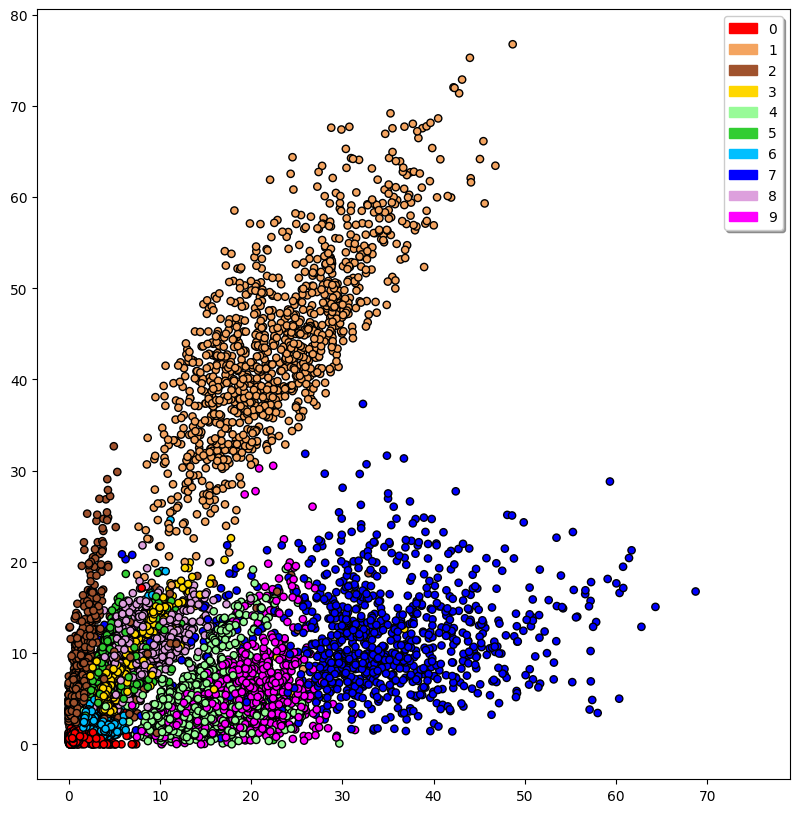

In [102]:
draw_scatter(.4, limits=None, filename='NB2-MLP-AE6-latent-scatter')

In [103]:
def draw_decoder_grid(steps=17, limits=None, filename=None):

    # display a 2D manifold of the digits
    digit_size = 28
    figure = np.zeros((digit_size * steps, digit_size * steps))
    grid_x = np.linspace(limits[1], limits[0], steps)
    grid_y = np.linspace(limits[2], limits[3], steps) 

    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            
            latents = np.array([[xi, yi]])
            decoder_prediction = AE6_decoder_only_model.predict(latents)
            
            digit = decoder_prediction[0].reshape(digit_size, digit_size)
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

    plt.figure(figsize=(10, 10))
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.imshow(figure, cmap='gray')
    file_helper.save_figure(filename)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━

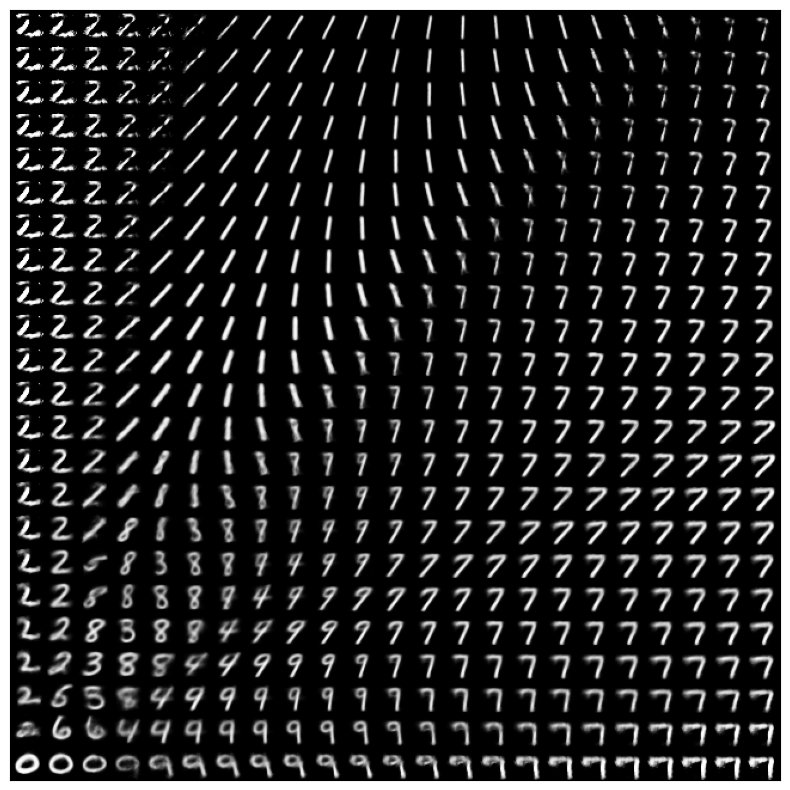

In [104]:
draw_decoder_grid(steps=23, limits=(0, 55, 0, 55), filename='NB2-MLP-AE6-17-decoder-grid')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


<Figure size 640x480 with 0 Axes>

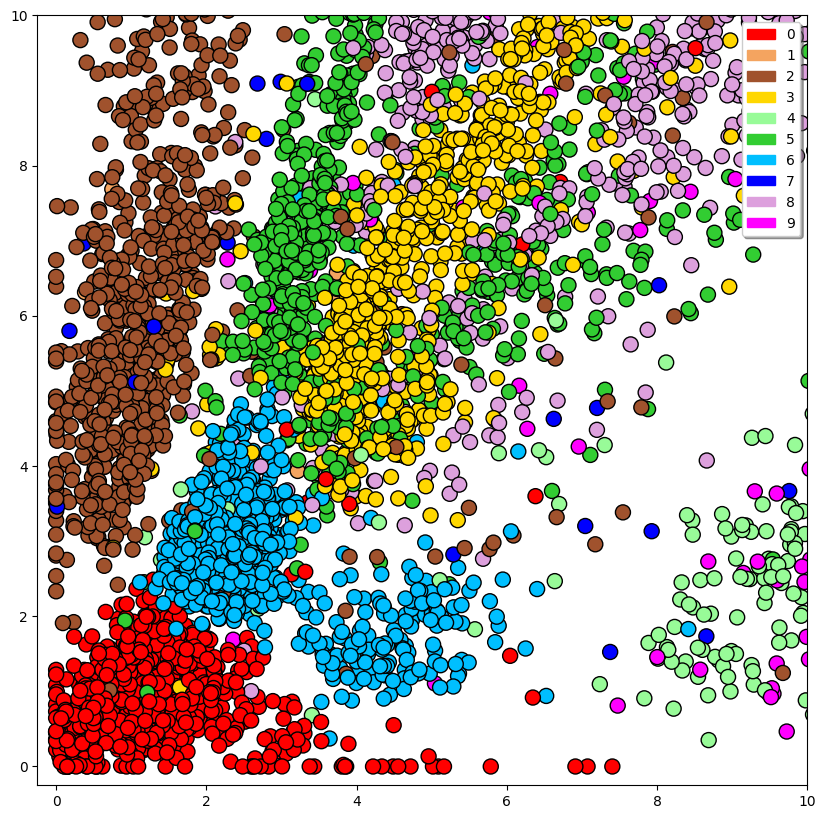

In [106]:
draw_scatter(.1, limits=(-.25, 10, -.25, 10), filename='NB2-MLP-AE6-latent-scatter-cu')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━

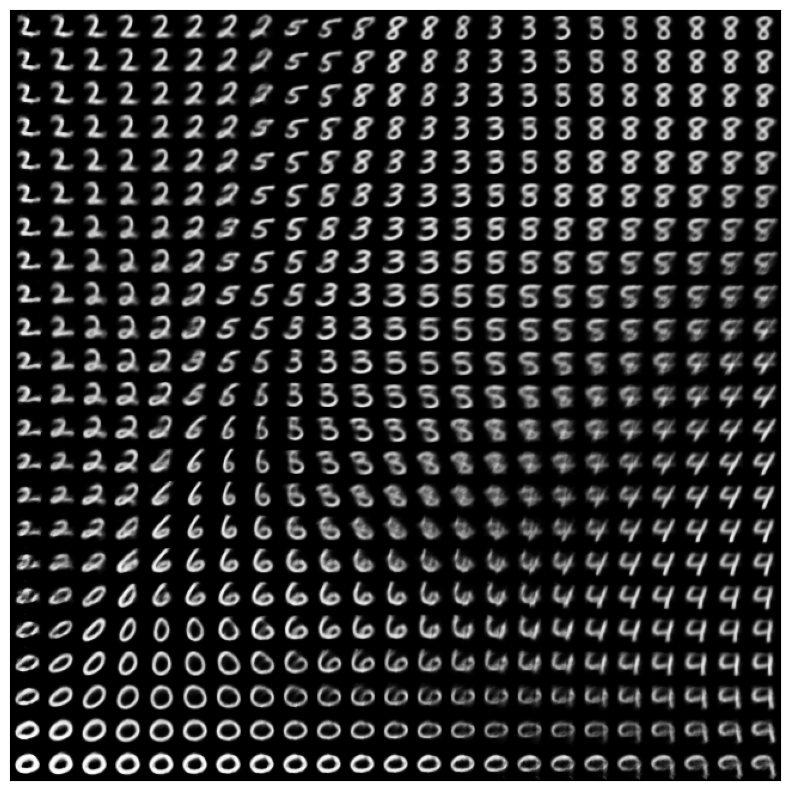

In [107]:
draw_decoder_grid(steps=23, limits=(-.25, 10, -.25, 10), filename='NB2-MLP-AE6-17-decoder-grid-CU')

In [112]:
def show_from_latents(latents_list, filename=None):
    numplots = len(latents_list)
    plt.clf()
    plt.figure(figsize=(4*numplots, 4))
    for i in range(numplots):
        latents = np.array(latents_list[i])
        latent_grid = np.resize(latents, (1,len(latents)))
        decoder_prediction = AE6_decoder_only_model.predict(latent_grid)
        plt.subplot(1, numplots, i+1)
        plt.imshow(np.reshape(decoder_prediction, (28,28)), cmap='gray')
        ax = plt.gca()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.tight_layout()
    file_helper.save_figure(filename)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


<Figure size 640x480 with 0 Axes>

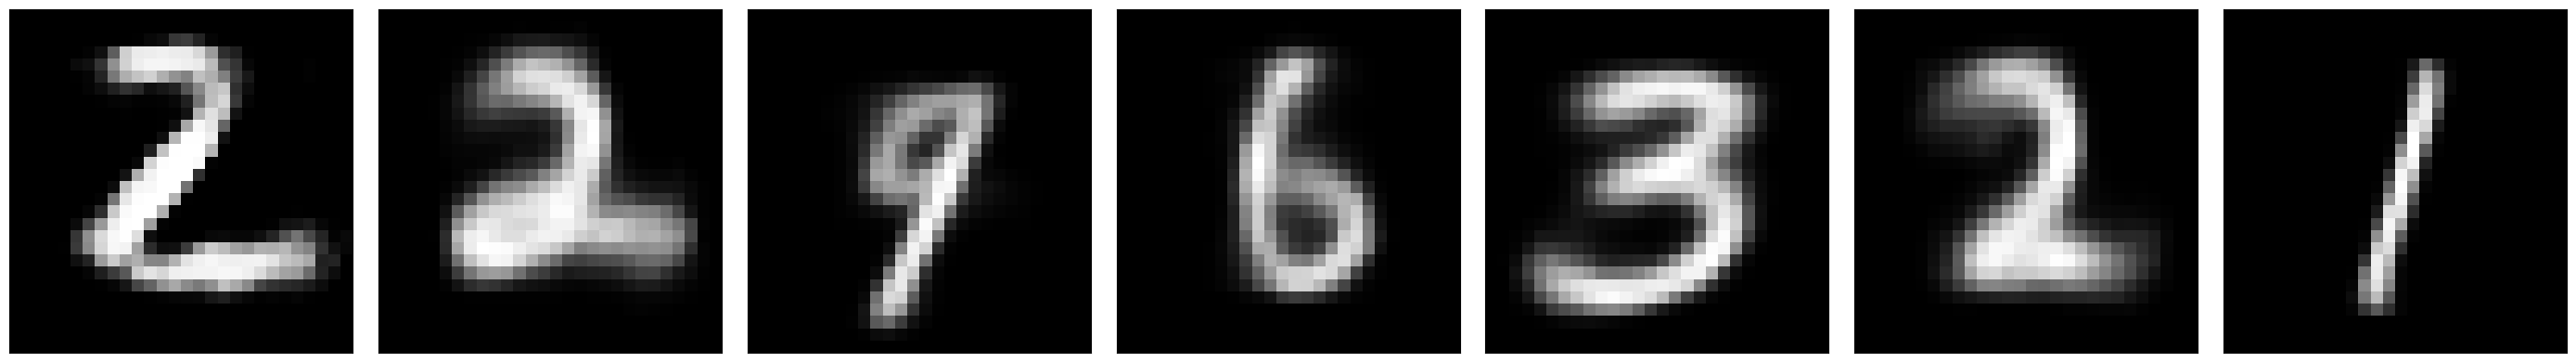

In [113]:
show_from_latents(
    ((2,30),(.5,5),(23,17),(3,4),(5,7),(1,8),(30,60)),
    #((2,0),(5,2),(4,6),(8,11),(35,55),(33.5,25), (40,13)), 
    'NB2-MLP-AE6-whitespace-predictions')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━

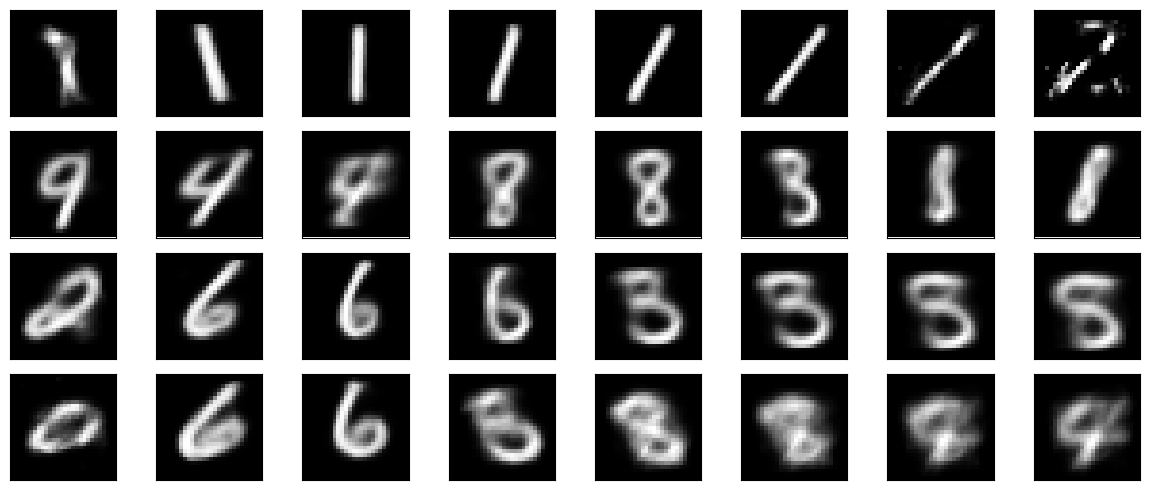

In [114]:
# blend latents for two test images and decompress
encoder_predictions = np.array(AE5_encoder_only_model.predict(X_test))
np.random.seed(random_seed)

steps = 8
plt.figure(figsize=(12, 5))
#latent0_list = [ (5,25), (6,.5), (3,3), (3,3)]
#latent1_list = [ (25, 60) , (30,5), (2,6), (30,35)]
latent0_list = [(30,35), (15,5), (1,3), (0,2)]
latent1_list = [(10,55), (10,20), (6,5), (9,5)]

for r in range(len(latent0_list)):
    latent0 = latent0_list[r]
    latent1 = latent1_list[r]
    for i in range(steps): 
        plt.subplot(len(latent0_list), steps, (steps*r)+(i+1))
        alpha = i/(steps-1.0)
        latent_mix = [latent0[i]+(alpha*(latent1[i]-latent0[i])) for i in range(len(latent0))]
        latent_mix = np.reshape(latent_mix, (1,len(latent_mix)))
        decoder_prediction = AE6_decoder_only_model.predict(latent_mix)
        plt.imshow(decoder_prediction.reshape(28, 28), cmap="gray")
        ax = plt.gca()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
plt.tight_layout()
file_helper.save_figure('NB2-MLP-AE6-blend-linear-through-scatter')
plt.show()